In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

KeyboardInterrupt: 

In [ ]:
img_size = (224,224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "datasets",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    "datasets",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 2082 images belonging to 2 classes.


Found 519 images belonging to 2 classes.


In [ ]:
print(train_data.class_indices)

{'Abnormal': 0, 'normal': 1}


### CNN Model

In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 376ms/step - accuracy: 0.8636 - loss: 0.5017 - val_accuracy: 0.9692 - val_loss: 0.1002
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 385ms/step - accuracy: 0.9577 - loss: 0.1277 - val_accuracy: 0.9788 - val_loss: 0.0764
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 391ms/step - accuracy: 0.9726 - loss: 0.0844 - val_accuracy: 0.9769 - val_loss: 0.0803
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 26s 390ms/step - accuracy: 0.9760 - loss: 0.0743 - val_accuracy: 0.9711 - val_loss: 0.0980
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 532ms/step - accuracy: 0.9870 - loss: 0.0481 - val_accuracy: 0.9692 - val_loss: 0.0980
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 437ms/step - accuracy: 0.9885 - loss: 0.0326 - val_accuracy: 0.9480 - val_loss: 0.1341
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 29s 439ms/step - accuracy: 0.9894 - loss: 0.0292 - val_accuracy: 0.9422 - val_loss: 0.1786
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 30s 457ms/step - accuracy: 0.9904 - loss: 0.0302 - val_accu

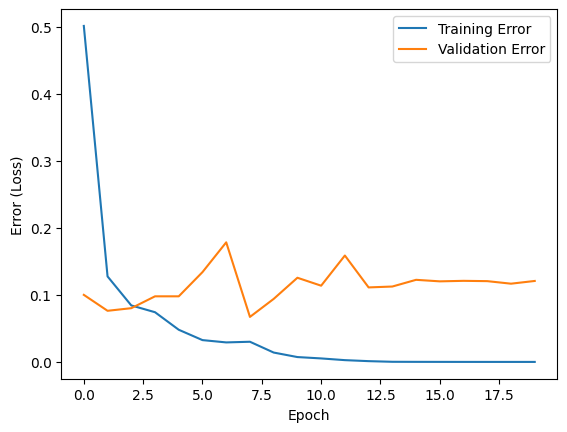

In [ ]:
plt.plot(history.history['loss'], label='Training Error')
plt.plot(history.history['val_loss'], label='Validation Error')

plt.xlabel("Epoch")
plt.ylabel("Error (Loss)")
plt.legend()

plt.show()

In [ ]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 1.0
Final Validation Accuracy: 0.9807322025299072


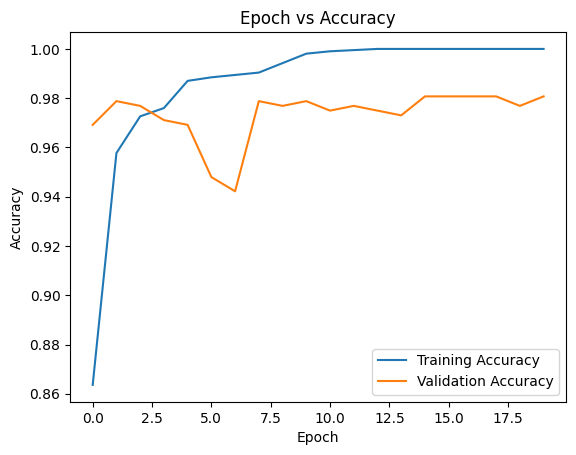

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Epoch vs Accuracy")
plt.legend()

plt.show()